# DI 501 - Introduction to Data Informatics 
### Regression

In this lab session we will quickly glance over utilities in scikit-learn and other libraries to aid regression tasks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import statsmodels.api as sm

In this first part we will go back to qs university rankings. We will analyze a preprocessed version of our dataset. We converted rank and overall score strings to floating point numbers, and removing redundant rank columns for each score.

Recall that calculating separate correlations for each score did not match the percentages reported by qs for overall score. To test the effect of a combination of variables multivariate regression can be utilized. As an exercise, let's first only use the score values to see if we can recover the weights ourselves.

In [15]:
qs = pd.read_csv('2026 QS Preprocessed.csv')

[missingno](https://github.com/ResidentMario/missingno) is a useful package when analyzing number and distribution of missing values in a dataset.

`msno.bar()` creates a bar chart that shows the completeness of each column.

* The height of the bar shows the number of non-missing values.

<Axes: >

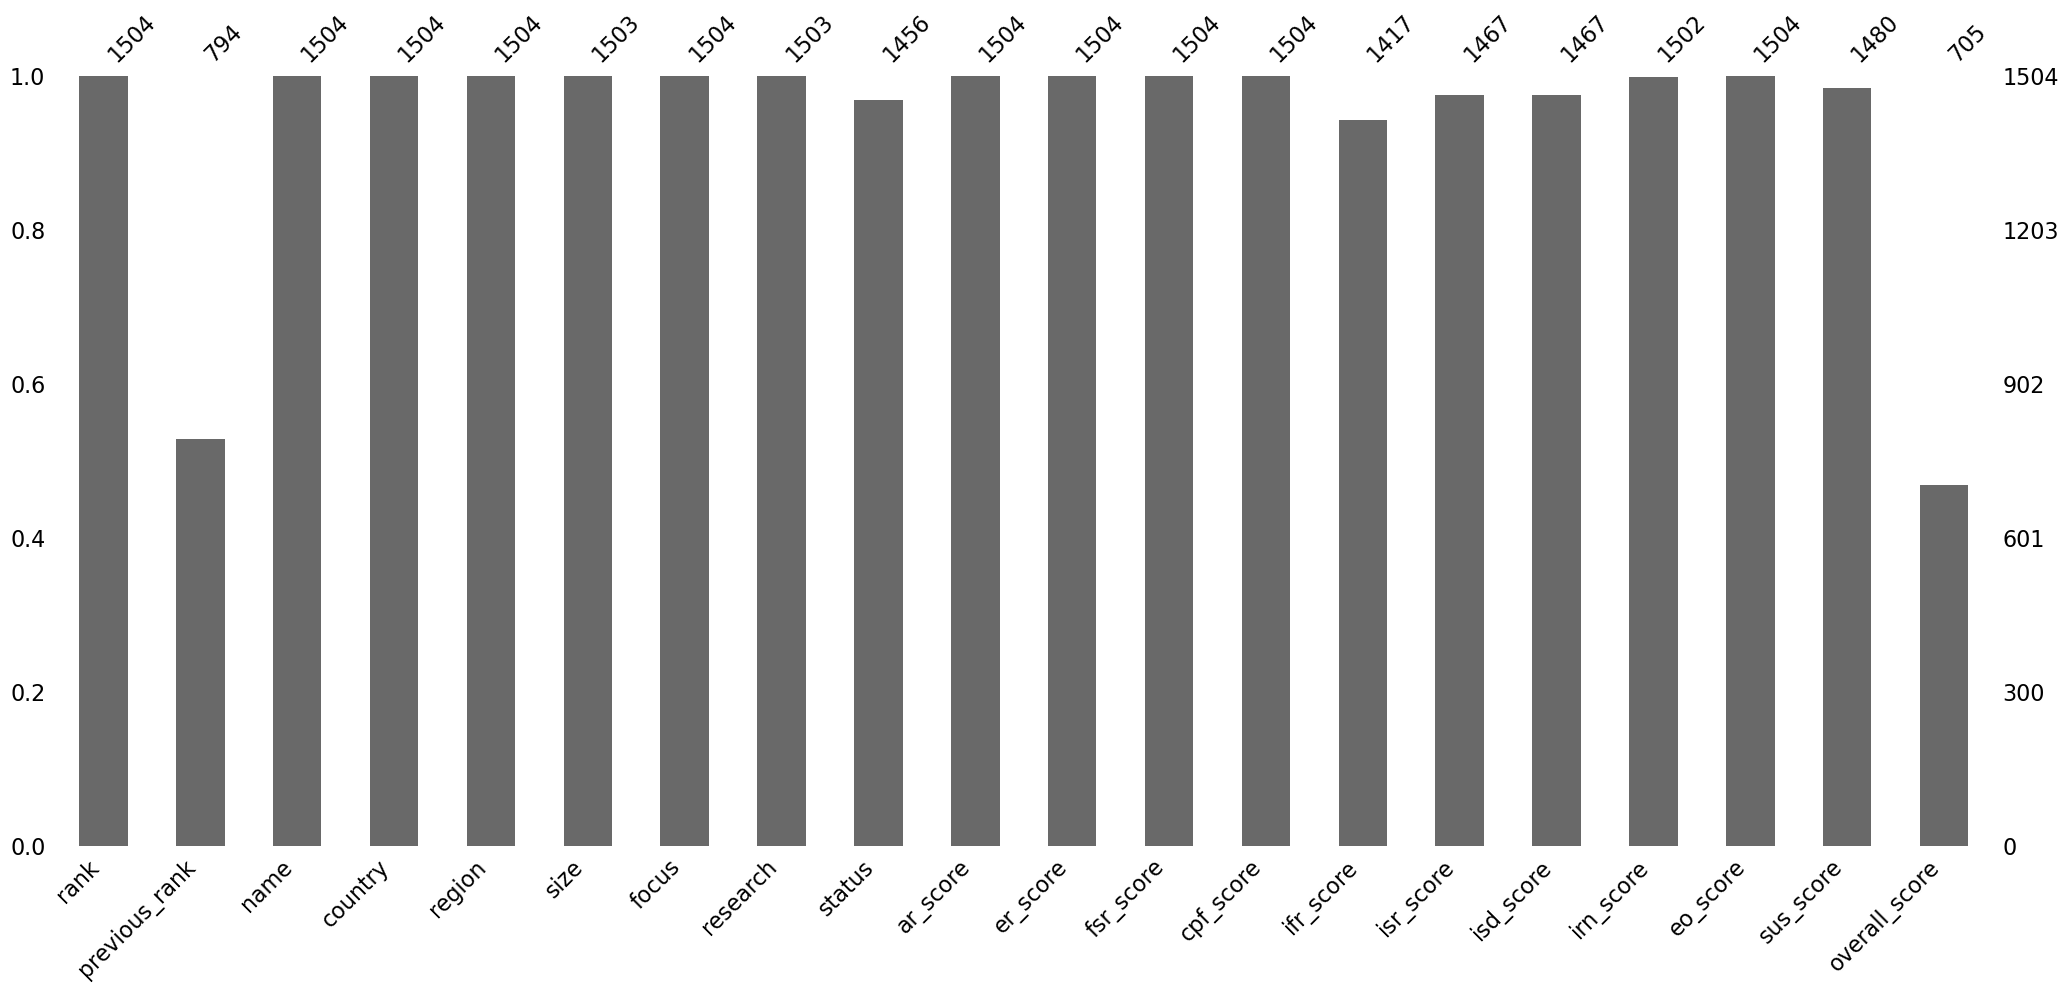

In [16]:
#!pip install missingno
import missingno as msno

msno.bar(qs)

`msno.matrix()` function provides a matrix visualization of missing data. It helps detect missing data patterns
and correlations between missingness.

<Axes: >

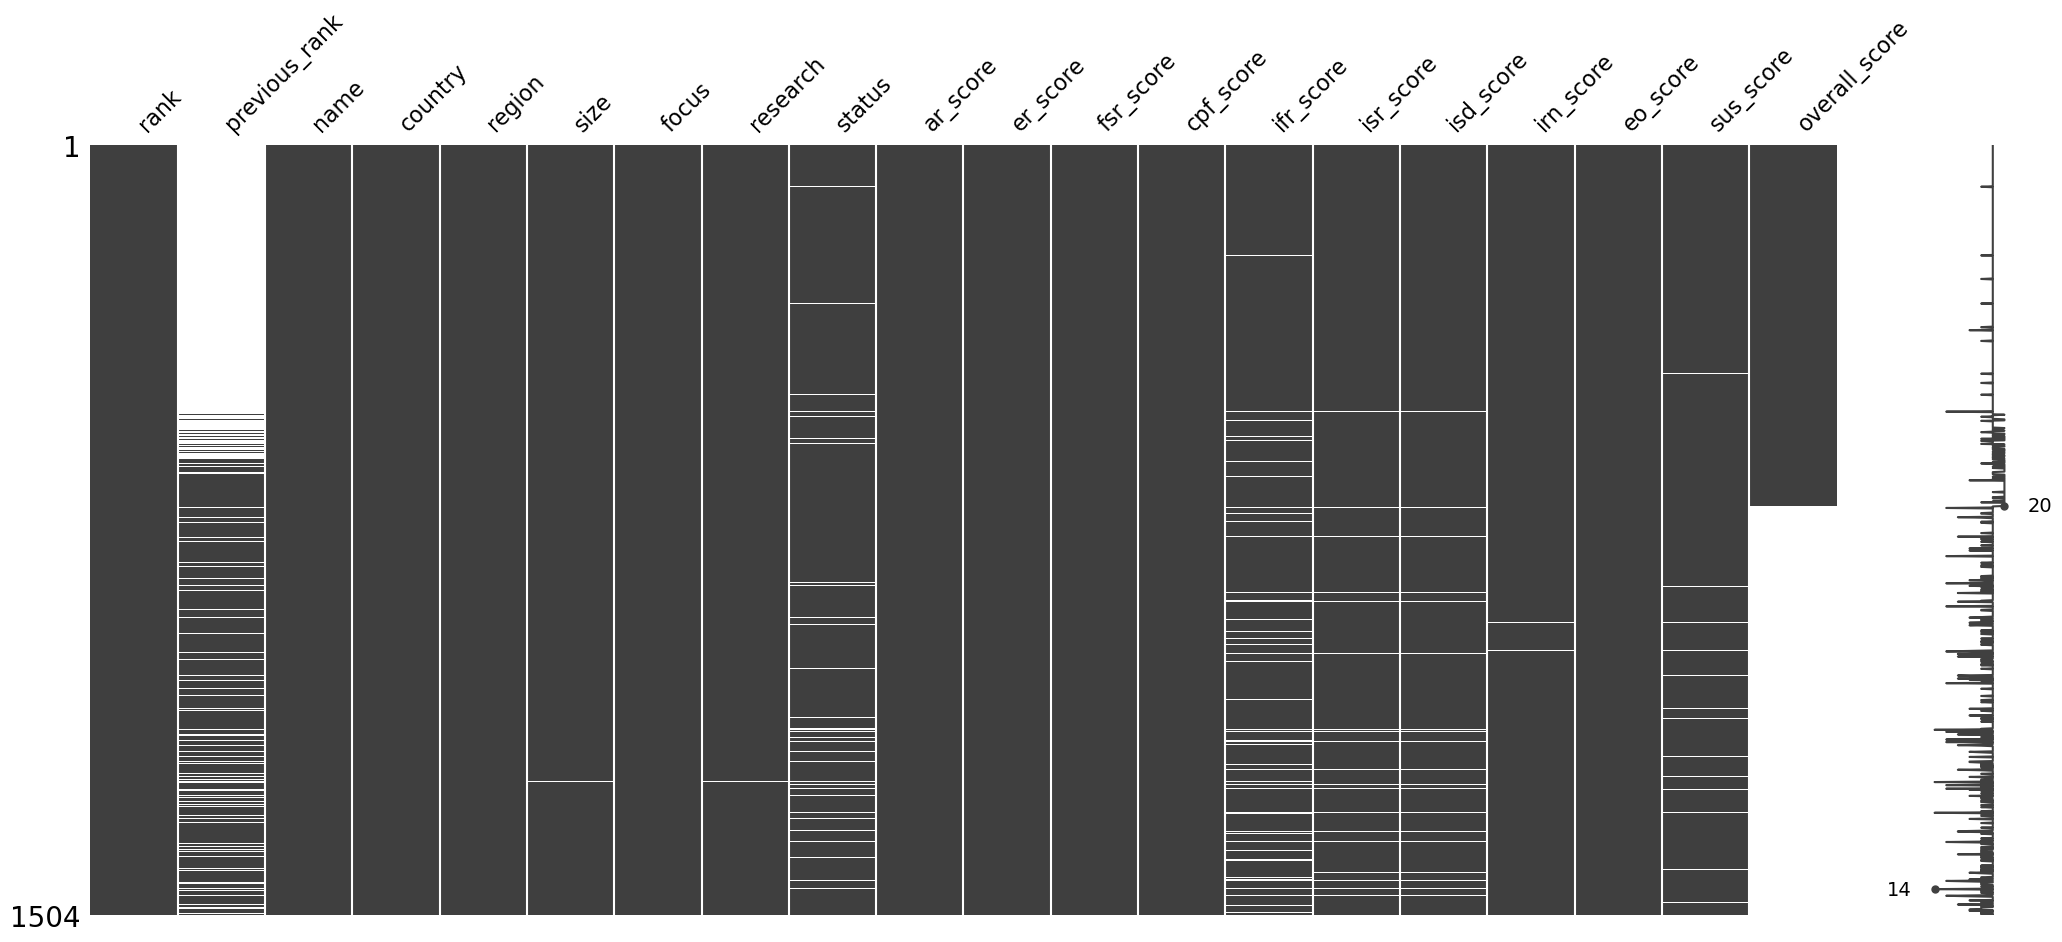

In [17]:
msno.matrix(qs)

`msno.heatmap()` shows how missing values are correlated across columns. Each cell shows a correlation between the missingness of two columns (using nullity correlation).

<Axes: >

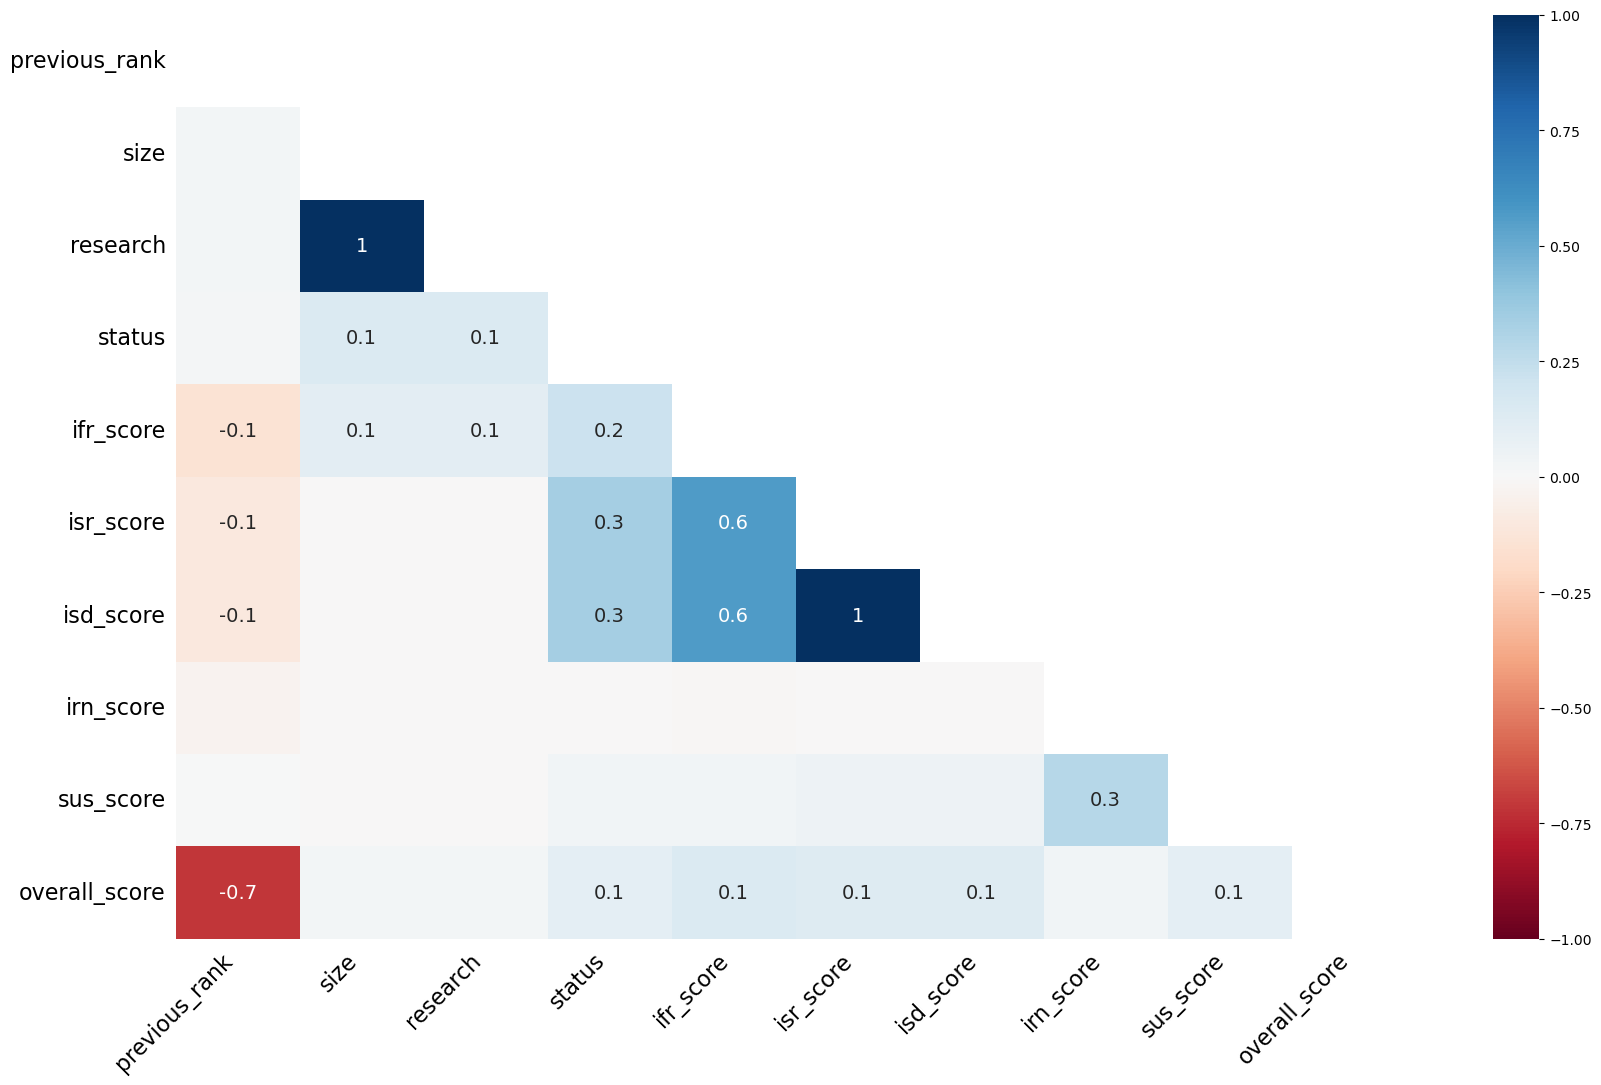

In [18]:
msno.heatmap(qs)

Let's only focus on scores, and drop rows with any missing values (including overall_score).

In [28]:
qs.dtypes

rank               int64
previous_rank    float64
name              object
country           object
region            object
size              object
focus             object
research          object
status            object
ar_score         float64
er_score         float64
fsr_score        float64
cpf_score        float64
ifr_score        float64
isr_score        float64
isd_score        float64
irn_score        float64
eo_score         float64
sus_score        float64
overall_score    float64
dtype: object

In [35]:
score_cols

['ar_score',
 'er_score',
 'fsr_score',
 'cpf_score',
 'ifr_score',
 'isr_score',
 'isd_score',
 'irn_score',
 'eo_score',
 'sus_score',
 'overall_score']

In [86]:
score_cols = [x for x in qs.columns if x.endswith('score')]

simple = qs[score_cols].dropna()

X = simple[score_cols[:-1]]
y = simple[score_cols[-1]]  # this is the target = overall_score

In [39]:
X.head()

,ar_score,er_score,fsr_score,cpf_score,ifr_score,isr_score,isd_score,irn_score,eo_score,sus_score
0,100.0,100.0,100.0,100.0,100.0,91.6,92.3,94.1,100.0,93.8
1,99.6,100.0,99.3,95.0,100.0,100.0,100.0,97.5,95.9,98.3
2,100.0,100.0,100.0,99.7,94.2,73.5,76.1,96.5,100.0,95.4
3,100.0,100.0,100.0,91.0,98.8,98.6,98.7,100.0,100.0,77.9
4,100.0,100.0,98.3,100.0,79.1,81.4,60.6,99.4,100.0,77.8


- We use Ordinary Least Squares (OLS) regression to examine how different performance metrics contribute to a university’s overall QS score.

- `summary()` provides detailed statistics — including coefficients, p-values, and R-squared — to help us interpret the contribution and significance of each feature.

In [40]:
lr = sm.OLS(y, X).fit()    
print(lr.summary())

                                 OLS Regression Results                                
Dep. Variable:          overall_score   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          9.634e+05
Date:                Tue, 17 Mar 2026   Prob (F-statistic):                        0.00
Time:                        23:45:58   Log-Likelihood:                         -388.96
No. Observations:                 689   AIC:                                      797.9
Df Residuals:                     679   BIC:                                      843.3
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## Question 1
Based on the regression summary table, what can you infer about the contribution of each feature to the overall QS score and their statistical significance? Explain your reasons.

* The most influential metric was ar_score (academic reputation) with a coefficient of 0.3076.

* cpf_score (citations per faculty) also had a strong effect (coefficient ≈ 0.20).


* The p-values are very small (≈ 0.000), meaning that there is strong evidence that each feature has a non-zero effect on the overall score and these features are not just randomly associated with the target; they are statistically significant predictors.

* The model’s The R-squared value of 1.000 tells us that the model fits the data perfectly — not because it’s a great predictive model, but because the features directly define the target. The regression model is not discovering something new, but confirming the strong mathematical link between the features and the target.

In fact these are the same as our original [percentages](https://support.qs.com/hc/en-gb/articles/4405955370898-QS-World-University-Rankings):

### Weights for overall rank

| Performances Lenses            | 2026 Edition Weights  |
|--------------------------------|-----------------------|
| Academic Reputation            | 30%                   |
| Citations per Faculty          | 20%                   |
| Employer Reputation            | 15%                   |
| Faculty/Student Ratio          | 10%                   |
| International Faculty Ratio    | 5%                    |
| International Student Ratio    | 5%                    |
| International Research Network | 5%                    |
| Employment Outcomes            | 5%                    |
| Sustainability                 | 5%                    |
| International Student Diversity| 0%                    |

Which is made even more evident by the following calculation.

This plot compares:

* Our reconstructed scores i.e. weighted sum of the components (x-axis) and 
* The actual overall_score column from the dataset (y-axis)

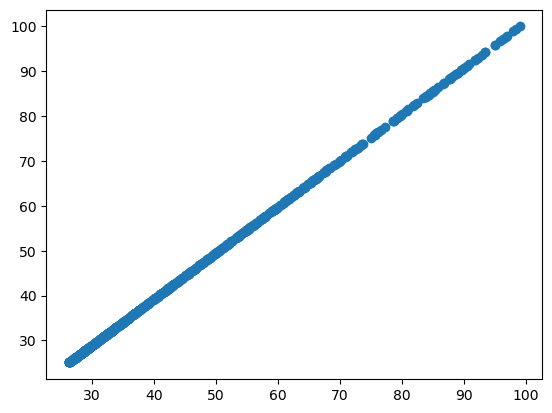

In [43]:
perc = pd.Series([0.3, 0.15, 0.1, 0.2, 0.05, 0.05, 0, 0.05, 0.05, 0.05], index=score_cols[:-1])

plt.scatter(np.sum(qs[score_cols] * perc, axis=1), qs.overall_score)

<Axes: >

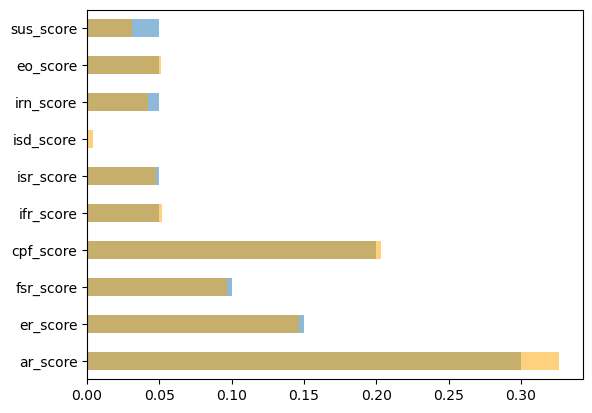

In [56]:
perc.plot(kind='barh',alpha=0.5)
lr.params.plot(kind='barh',alpha=0.5,color='orange')

Here you can see the predicted weights align well with the real ones, but there are some discrepancies, mainly in sus_score and ar_score.

In [87]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

lasso = Lasso()

lasso.fit(X, y)

lasso.predict(X)

/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


array([98.71790212, 98.09863471, 97.63930709, ...,  9.78397565,
       10.48217976,  9.0073509 ], shape=(1392,))

In [88]:
lasso.coef_

array([0.31574693, 0.14590194, 0.09760833, 0.19856846, 0.04885727,
       0.05048348, 0.        , 0.04594868, 0.04947219, 0.04238861])

In [89]:
perc.values

array([0.3 , 0.15, 0.1 , 0.2 , 0.05, 0.05, 0.  , 0.05, 0.05, 0.05])

/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.499e+02, tolerance: 5.724e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_mod

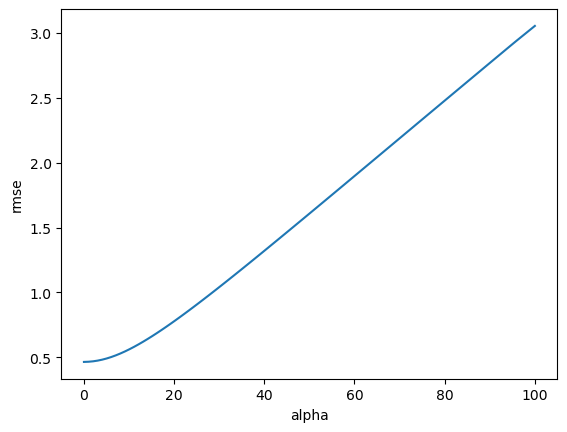

In [95]:
alphas = np.linspace(0,100,100)

"""
This line generates a range of values for alpha from 0.0001 to 1.0 with a step size of 0.01.
* Alpha controls the strength of the regularization. 
* A higher alpha value means stronger regularization, while a lower alpha means less regularization.
"""

rmse = []

for alpha in alphas:
    lasso = ElasticNet(alpha=alpha, l1_ratio=0.5)
    lasso.fit(X, y)
    y_predr = lasso.predict(X)

    rmse.append(mean_squared_error(y_predr, y)**0.5)

plt.plot(alphas, rmse)
plt.xlabel('alpha')
plt.ylabel('rmse');

The points lie almost perfectly on a diagonal line, meaning the reconstructed scores are almost exactly the same as the original ones.
This confirms that QS really does use these weights to calculate the overall_score.

Let's then fill in the missing overall scores by multiplying the existing feature values from qs[num_cols[:-1]] with the corresponding weights (perc), and summing them up (if the values exist).


In [57]:
updated = qs.overall_score.fillna((qs[score_cols[:-1]].fillna(0) * perc).sum(axis=1))

updated

0       100.000
1        99.400
2        98.900
3        97.900
4        97.700
         ...   
1499      9.890
1500      9.580
1501      9.995
1502     10.610
1503      8.930
Name: overall_score, Length: 1504, dtype: float64

In [58]:
qs.loc[:,'overall_score'] = updated

The missing values in the overall_score column are now filled with the calculated values based on the weighted sum of the features.

## Effect of additional features

Recall the definition of our categorical variables. Since the categories have an inherent order, it is crucial to encode them with integer values that reflect this ordering. This is different from one-hot encoding, where categories are represented by binary variables without considering their natural order. By using integers, we preserve the order information, which is valuable for models that can utilize this hierarchy.

<table>

<td>

|    | Size        | Students         |
|----|-------------|------------------|
| XL | Extra Large | >=30,000 |
| L  | Large       | >=12,000         |
| M  | Medium      | >=5,000          |
| S  | Small       | <5,000 |

</td>
<td>

|    | Focus              | Faculty Area                         |
|----|--------------------|--------------------------------------|
| FC | Full comprehensive | All 5 faculty areas + medical school |
| CO | Comprehensive      | All 5 faculty areas                  |
| FO | Focused            | 3 or 4 faculty areas                 |
| SP | Specialist         | 2 or fewer faculty areas             |

</td>
<td>

|    | Research Intensity |
|----|--------------------|
| VH | Very High          |
| HI | High               |
| MD | Medium             |
| LO | Low                |

</td>
</table>

In [59]:
qs['size'].unique()

array(['M', 'L', 'XL', 'S', nan], dtype=object)

In [60]:
qs['research'].unique()

array(['VH', 'HI', 'MD', 'LO', nan], dtype=object)

In [61]:
qs['focus'].unique()

array(['CO', 'FO', 'FC', 'SP'], dtype=object)

In [62]:
qs['status'].unique()

array(['Private not for Profit', 'Public', nan, 'Private for Profit'],
      dtype=object)

In [63]:
from sklearn.preprocessing import OrdinalEncoder

qs_na = qs.dropna()

size_enc = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])

qs_na.loc[:,'size'] = size_enc.fit_transform(qs_na['size'].values.reshape(-1,1))  # the encoder expects the data to be in a 2D shape (n_samples, n_features).

In [64]:
res_enc = OrdinalEncoder(categories=[['LO', 'MD', 'HI', 'VH']])

qs_na.loc[:,'research'] = res_enc.fit_transform(qs_na.research.values.reshape(-1,1))

In [65]:
focus_enc = OrdinalEncoder(categories=[['SP', 'FO', 'CO', 'FC']])

qs_na.loc[:,'focus'] = focus_enc.fit_transform(qs_na.focus.values.reshape(-1,1))

In [68]:
qs_na = qs_na.astype({'rank':float,
                      'size':int,
                      'research':int,
                      'focus':int})

In [70]:
qs_na.region.value_counts()

region
Asia        262
Europe      206
Americas    203
Africa       21
Oceania       6
Name: count, dtype: int64

## Question 2

For the continent column, apply appropriate encoder and explain your reasoning.

In [71]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(sparse_output=False).fit(qs_na.region.values.reshape(-1,1))

onehot.categories_

[array(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'], dtype=object)]

In [73]:
continents = onehot.transform(qs_na.region.values.reshape(-1,1))

continents

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.]], shape=(698, 5))

- pd.get_dummies is easier and faster for use directly on DataFrames.
 - OneHotEncoder (from scikit-learn) gives more control, especially when you're using pipelines, or working with train/test splits and want to avoid column mismatch.

In [75]:
qs_na = pd.get_dummies(qs_na, columns=['region'])

In [76]:
qs_na.head()

,rank,previous_rank,name,country,size,focus,research,status,ar_score,er_score,...,isd_score,irn_score,eo_score,sus_score,overall_score,region_Africa,region_Americas,region_Asia,region_Europe,region_Oceania
526,526.0,631.0,Boston College,United States of America,2,2,3,Private not for Profit,29.9,30.2,...,34.5,47.7,64.8,56.0,30.9,False,True,False,False,False
535,535.0,601.0,King Khalid University,Saudi Arabia,2,3,3,Public,25.8,17.6,...,26.9,84.4,2.7,45.7,30.6,False,False,True,False,False
536,535.0,701.0,Lebanese American University,Lebanon,1,3,2,Private not for Profit,20.2,44.6,...,31.7,78.3,29.2,58.3,30.6,False,False,True,False,False
537,535.0,681.0,Prince Sultan University,Saudi Arabia,0,0,3,Private not for Profit,10.6,12.0,...,24.7,62.7,15.9,45.7,30.6,False,False,True,False,False
552,551.0,641.0,Universiti Tenaga Nasional (UNITEN),Malaysia,0,0,3,Private for Profit,9.5,19.9,...,65.6,55.7,5.3,48.7,29.9,False,False,True,False,False


In [77]:
qs_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 698 entries, 526 to 1503
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             698 non-null    float64
 1   previous_rank    698 non-null    float64
 2   name             698 non-null    object 
 3   country          698 non-null    object 
 4   size             698 non-null    int64  
 5   focus            698 non-null    int64  
 6   research         698 non-null    int64  
 7   status           698 non-null    object 
 8   ar_score         698 non-null    float64
 9   er_score         698 non-null    float64
 10  fsr_score        698 non-null    float64
 11  cpf_score        698 non-null    float64
 12  ifr_score        698 non-null    float64
 13  isr_score        698 non-null    float64
 14  isd_score        698 non-null    float64
 15  irn_score        698 non-null    float64
 16  eo_score         698 non-null    float64
 17  sus_score        6

In [79]:
cat = [col for col,dtype in zip(qs_na.columns, qs_na.dtypes) if dtype not in ['object','float64']]

In [80]:
new_X = sm.add_constant(qs_na[cat])
# new_X = sm.add_constant(qs_na[cat + num_cols[:-1]])

"""
The sm.add_constant() function is used to manually add an intercept term
to the regression model when using statsmodels.OLS(), 
since it does not include one by default. 
Adding a constant allows the model to estimate the baseline value
of the dependent variable, leading to more accurate predictions.
"""

'\nThe sm.add_constant() function is used to manually add an intercept term\nto the regression model when using statsmodels.OLS(), \nsince it does not include one by default. \nAdding a constant allows the model to estimate the baseline value\nof the dependent variable, leading to more accurate predictions.\n'


The general linear regression model is written as:

y = β₀ + β₁·x₁ + β₂·x₂ + ... + βₙ·xₙ + ε


Here:

- β₀ is the intercept (constant term),
- β₁, β₂, ..., βₙ are the coefficients for the independent variables,
- ε is the error term.

Unlike some libraries (like `scikit-learn`), `statsmodels.OLS()` **does not include an intercept by default**.  
Therefore, we use `sm.add_constant()` to explicitly add this term to the model.

Without adding a constant, the model assumes the intercept is zero, which can lead to **biased or inaccurate predictions**, especially when the true relationship includes a non-zero baseline effect.


In [81]:
y = qs_na['overall_score']

model2 = sm.OLS(y, new_X.astype(int)).fit()

In [82]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          overall_score   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     16.58
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.84e-20
Time:                        23:53:09   Log-Likelihood:                -2147.9
No. Observations:                 698   AIC:                             4312.
Df Residuals:                     690   BIC:                             4348.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4561      0.990     

## Another case

This time we will focus on a dataset of solar panel generation and many weather related columns. Since we are not given any column information, we don't know whether it makes sense to include all of them. Let's see what we can find when going in blind.

In [98]:
pvm = pd.read_csv('pv_data.csv',index_col=0)

In [99]:
pvm.head()

,U2M,V250,TROPT,TROPPB,T2M,TQL,T500,TOX,U850,PS,...,QV10M,LWGAB,SWLAND,PRECLSCORR,PRECCUCORR,PARDF,SWGDN,PRECSNOCORR,PARDR,generation_mw
2023-07-01 00:30:00+00:00,3.327844,-5.805844,216.74097,22642.006,289.18585,0.056580,262.92240,0.006956,11.825224,99506.375,...,0.010958,356.78640,0.000000,0.000009,0.0,0.000000,0.000000,0.0,0.000000e+00,0.000000
2023-07-01 01:30:00+00:00,3.342380,-3.687345,217.28345,22640.912,289.10156,0.066910,262.53152,0.006989,11.602690,99449.790,...,0.010891,362.62750,0.000000,0.000010,0.0,0.000000,0.000000,0.0,0.000000e+00,0.000000
2023-07-01 02:30:00+00:00,3.328679,-8.294871,219.20236,22640.520,288.96063,0.064224,262.60430,0.007075,11.525191,99417.880,...,0.010809,359.93237,0.000000,0.000010,0.0,0.000000,0.000000,0.0,0.000000e+00,0.000000
2023-07-01 03:30:00+00:00,3.249641,-17.971140,219.84341,22640.268,288.69244,0.082779,262.71985,0.007095,11.408081,99412.750,...,0.010691,352.54960,0.222715,0.000010,0.0,0.088955,0.279740,0.0,3.613666e-08,0.000000
2023-07-01 04:30:00+00:00,3.387968,-24.947979,220.24130,22641.637,288.70657,0.111969,262.56800,0.007049,10.805376,99430.125,...,0.010579,356.35510,20.794027,0.000008,0.0,9.155069,27.317741,0.0,1.576914e+00,1.152103


In [100]:
pvm.shape

(1512, 56)

In [101]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [102]:
X, y = pvm.iloc[:,:-1], pvm.generation_mw

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=1337)

lr_pipe = make_pipeline(StandardScaler(), LinearRegression()) # creates a pipeline with standard scaling (to normalize the features) and linear regression
print(lr_pipe)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])


In [103]:
lr_pipe.fit(X_train, y_train)

y_pred_train = lr_pipe.predict(X_train)
y_pred_val = lr_pipe.predict(X_val)
y_pred_test = lr_pipe.predict(X_test)

print(f'RMSE (Train) for Linear Regression: {mean_squared_error(y_pred_train, y_train)**0.5:.3f}') 
print(f'RMSE (Val) for Linear Regression: {mean_squared_error(y_pred_val, y_val)**0.5:.3f}')
print(f'RMSE (Test) for Linear Regression: {mean_squared_error(y_pred_test, y_test)**0.5:.3f}')

RMSE (Train) for Linear Regression: 15.150
RMSE (Val) for Linear Regression: 13.980
RMSE (Test) for Linear Regression: 19.589


/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-p

We are using root mean squared error to analyze the performance against all of our splits. By chance, validation error seems even smaller than training error, but what is telling is the bigger error on the test set. This means our model cannot interpolate to unseen examples.

Note that different tasks require different error metrics. See [here](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics) for information on different implementations in scikit-learn. (You can of course use your own metrics if necessary.)

In [104]:
lr_pipe[1].coef_

array([-3.32395684e+01,  3.42326910e-01,  3.65610787e+00, -7.27084894e+00,
       -3.74486875e+01, -3.96760665e+00, -3.31539159e+00, -2.90884787e+02,
        1.47960464e+00, -5.48735383e+02, -3.43073379e+00,  2.11015855e+00,
        3.63230714e+00, -6.66521468e-01,  4.70014824e+02,  1.55131221e+00,
       -3.14876114e+09, -1.23207927e+01,  3.11397926e-01, -2.33231862e-01,
        1.56045828e+02,  2.91706828e+02,  3.32044292e+01,  3.01085231e+01,
        6.65257181e-01,  1.64778393e+00,  4.14046791e+02, -2.14078292e+00,
        2.86917168e+00, -9.00744874e+00, -3.13970483e+00, -3.46258038e+00,
        3.26772864e+00,  2.32849407e+00,  2.12783764e+01, -1.99039253e+01,
        1.15874620e+01, -5.89267600e+00,  3.47805817e+01,  2.91281760e+00,
        3.14876114e+09,  3.60834118e-01,  4.73065615e-01,  5.48401929e-01,
       -4.92798689e+02,  9.89791811e-01,  2.89956722e+00,  1.55403972e+00,
        1.96674095e+02,  1.71274436e+00,  9.01867338e-01,  4.15471658e-01,
       -1.51834374e+02,  

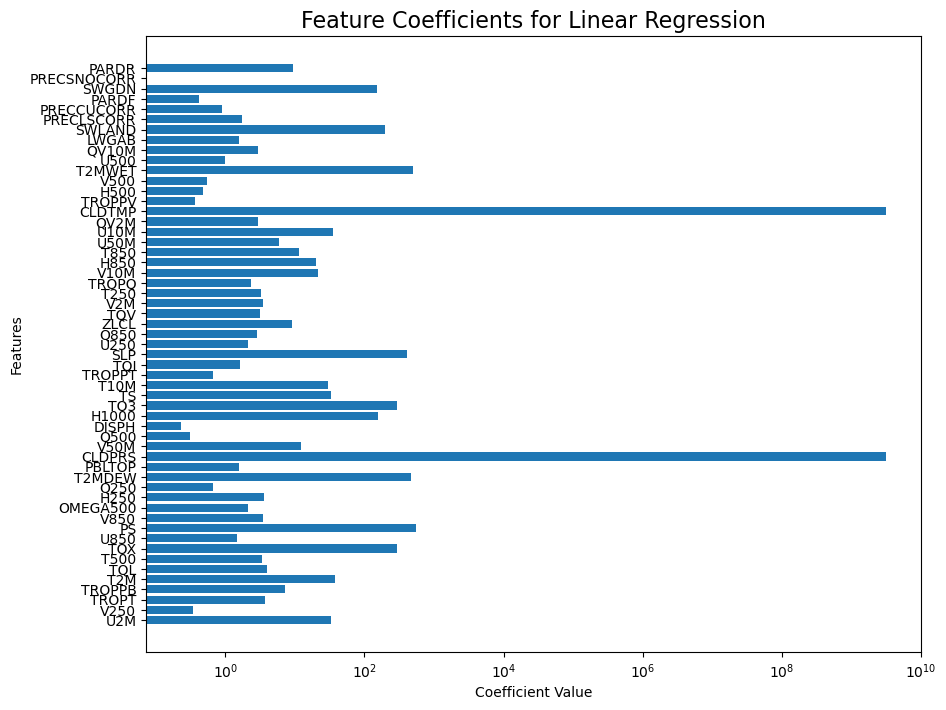

In [105]:
plt.figure(figsize=(10,8))
plt.barh(width=np.abs(lr_pipe[1].coef_), y=pvm.columns[:-1])

plt.title('Feature Coefficients for Linear Regression', size=16)
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.xscale('log')

## Question 3
What could be the reason why most of the parameters (features) have coefficients close to zero, while some explode to billions? What could this indicate about the model or the data?

While most parameters are zero, some explode to billions. There could be a few factors at play:

* Either the model overfit to specific columns
* Or the parameters are out of scale (which was solved by the StandardScaler)

Let's investigate the first point by utilizing ElasticNet with half L1 and L2 losses.

/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.459e+05, tolerance: 3.357e+02
  model = cd_fast.enet_coordinate_descent(
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-pa

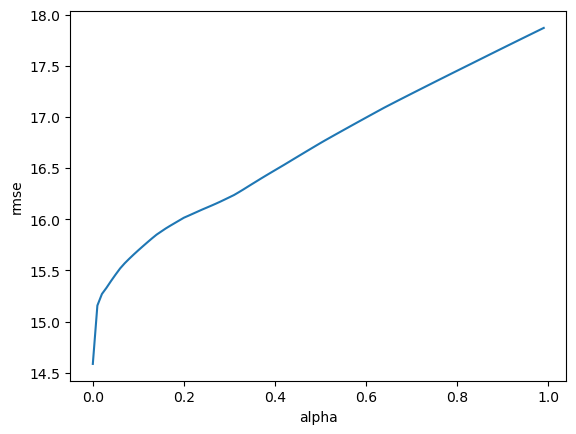

In [106]:
alphas = np.arange(1,10000,100)/10000

"""
This line generates a range of values for alpha from 0.0001 to 1.0 with a step size of 0.01.
* Alpha controls the strength of the regularization. 
* A higher alpha value means stronger regularization, while a lower alpha means less regularization.
"""

rmse = []

for alpha in alphas:
    r_pipe = make_pipeline(StandardScaler(), ElasticNet(alpha=alpha, l1_ratio=0.5))

    """ 
    Here, we use ElasticNet with a mix of L1 and L2 regularization:
    * alpha controls the overall regularization strength.
    * l1_ratio=0.5 means the loss function will equally balance L1 (Lasso) and L2 (Ridge) penalties. 
    An L1 ratio of 0.5 means 50% Lasso and 50% Ridge. 
    """
    
    r_pipe.fit(X_train, y_train)
    y_predr = r_pipe.predict(X_val)

    rmse.append(mean_squared_error(y_predr, y_val)**0.5)

plt.plot(alphas, rmse)
plt.xlabel('alpha')
plt.ylabel('rmse');

Even though the RMSE is lowest when alpha = 0, this corresponds to standard linear regression with no regularization. In this case, neither L1 nor L2 penalties are applied, which eliminates the benefits of regularization and feature selection.

By choosing a small but non-zero value like alpha = 0.1, we retain some regularization.

In [111]:
r_pipe = make_pipeline(StandardScaler(), ElasticNet(alpha=.5, l1_ratio=.5))

r_pipe.fit(X_train, y_train)

y_predr = r_pipe.predict(X_test)

print(f'RMSE for ElasticNet with alpha={r_pipe[1].alpha}: {mean_squared_error(y_predr, y_test)**0.5:.3f}')

RMSE for ElasticNet with alpha=0.5: 19.455


/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/volga/miniconda3/envs/heasoft/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


We can see using any of the other alpha than 0 (equivalent to linear_regression) does not seem optimal. Picking the next best alpha value seems to make a small improvement, but not by much.